# Step 4 - How many laps, and when?
> Find out how many laps the car drove as well as the start and end time for each lap. The car has a GPS system you can utilize to visualize this.

In [5]:
import polars as pL
import numpy as np
import matplotlib.pyplot as plt

pd = pL.read_parquet("../software-data.parquet")
pd = pd.fill_null(strategy="forward")

rpm = pd["SME_TRQSPD_Speed"]
time = pd["Time"]

gear_ratio = 12/41
radius = .2                             #in meters

def meters_second(rpm):
    speed_mps = (rpm * gear_ratio * 2 * 3.14159 * radius) / 60  # Convert rpm to m/s
    return speed_mps

speed = meters_second(rpm)
moving = speed > 0.1

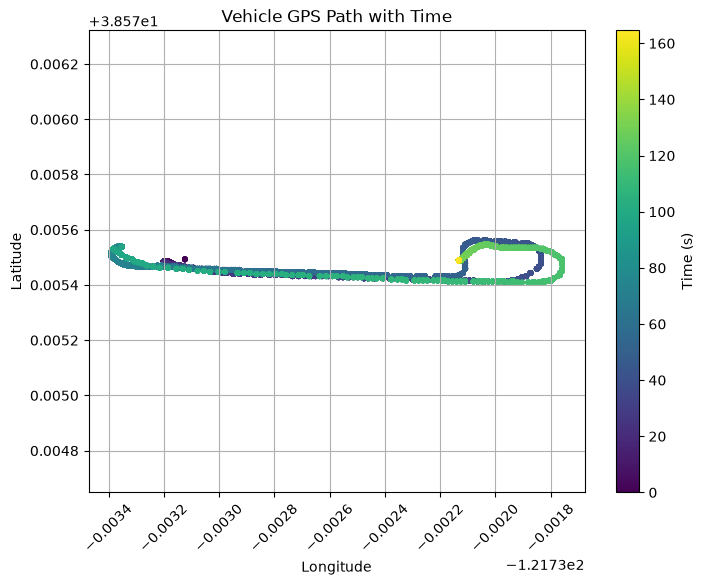

In [3]:
lati = pd["VDM_GPS_Latitude"]
longi = pd["VDM_GPS_Longitude"]

plt.figure(figsize=(8, 6))
plt.scatter(longi, lati, c=time, cmap='viridis', s=10)
plt.colorbar(label='Time (s)')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Vehicle GPS Path with Time")
plt.grid(True)
plt.axis('equal')
plt.xticks(rotation=45)
plt.show()

The path is a straight out-and-back: the car drives to the far end, turns around and comes back. Longitude shows this best, since the straight runs east-west.

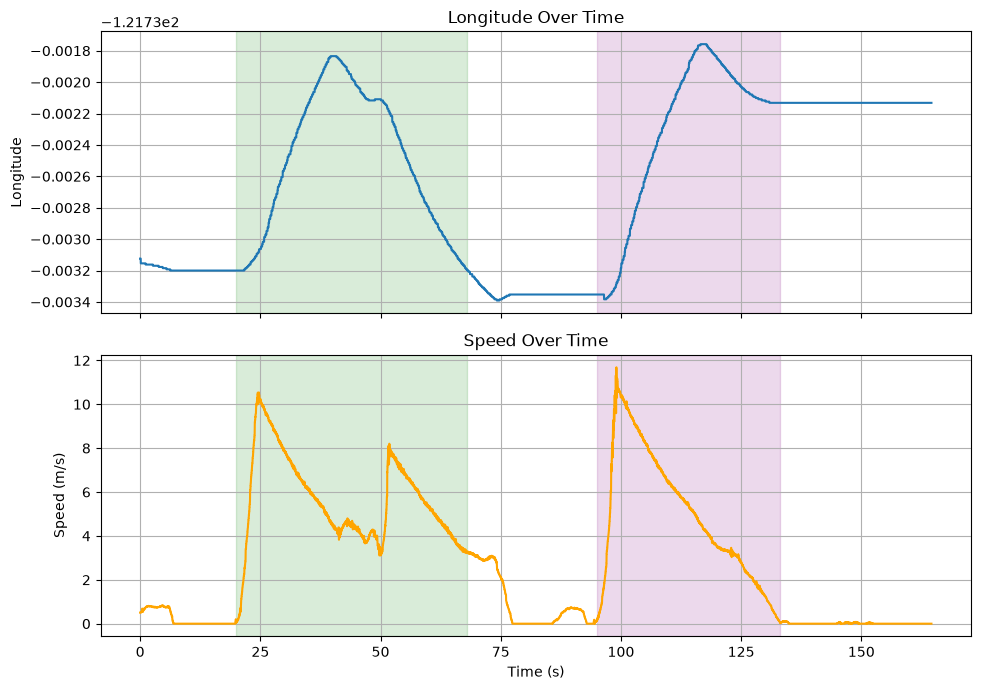

In [4]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 7))

axes[0].plot(time, longi, label="Longitude")
axes[0].set_ylabel("Longitude")
axes[0].grid(True)
axes[0].set_title("Longitude Over Time")

axes[1].plot(time, speed, label="Speed (m/s)", color='orange')
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Speed (m/s)")
axes[1].grid(True)
axes[1].set_title("Speed Over Time")

# lap windows
for ax in axes:
    ax.axvspan(20, 68, color='green', alpha=0.15)
    ax.axvspan(95, 133, color='purple', alpha=0.15)

plt.tight_layout()
plt.show()

## Answer: 1.5 laps

| Lap | Start | End |
|---|---|---|
| 1 | 20 s | 68 s |
| 2 | 95 s | 133 s (car stops - never crosses back over the start line) |

**Lap definition:** a lap starts when the car pulls away from rest at the start area, drives to the far end, turns around, and ends when it crosses back over the start-line longitude.

**Why "pulls away from rest" and not "crosses the start line":** before Lap 2 the car was parked ~14 m behind the start line (longitude -121.733353 vs. about -121.733200). It did its whole launch (0 -> ~11.7 m/s) before reaching the line, and only crossed it at ~99.95 s. Using the crossing would cut the launch and top speed out of Lap 2.

**Start times:** the last time speed was ~0 (<= 0.1 m/s) before each launch, checked against the pedal (throttle rises right before each launch): Lap 1 at ~20.1 s, Lap 2 at ~94.8 s.

**Side note:** GPS longitude barely changes during the first seconds of each launch even though the car is moving (it stays at -121.733353 from 85 s to ~96 s). GPS updates slowly, so motor speed is better for finding exactly when the car starts moving.